# 학습 목표
- 데이터를 그룹화하고 집계함수를 통해 간단한 통계를 낼 수 있다.
- 그룹화된 데이터를 중복없이 집계할 수 있다.
- 그룹핑된 데이터에 조건을 주어 더 세부적으로 추출할 수 있다.

In [1]:
# 학습준비

import os
import pandas as pd 
from pandasql import sqldf
mysql = lambda q: sqldf(q, globals())

data_dir = './data/'

bike = pd.read_csv(os.path.join(data_dir, 'bike_dataset.csv'))
orders = pd.read_csv(os.path.join(data_dir, 'orders.csv'))
customers = pd.read_csv(os.path.join(data_dir, 'customers.csv'))
employees = pd.read_csv(os.path.join(data_dir,'employees.csv'))
ds_2020 = pd.read_csv(os.path.join(data_dir, 'DS_JobsSalaries_2020.csv'))
ds_2021 = pd.read_csv(os.path.join(data_dir, 'DS_JobsSalaries_2021.csv'))


# 집계함수(COUNT, SUM, AVG, MAX, MIN)

## 1. COUNT

### COUNT(*)
- 모든 행의 개수를 카운트한다.
- NULL을 포함
- 컬럼의 NULL값 유무 체크할 수 없음

### COUNT(컬럼명)
- NULL값 제외 컬럼명의 행의 갯수 출력

In [2]:
# 날씨 데이터의 값이 NULL값인 전체 데이터를 추출

mysql("""

SELECT *
FROM bike
WHERE weathersit IS NULL

""")

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-02-19,spring,2011,Feb,11,0,Saturday,0,None,0.44,0.4394,0.16,0.5821,47,76,123


In [3]:
# 전체 컬럼과 weathersit 컬럼의 개수를 확인

mysql("""
 
SELECT COUNT(*) AS cnt
      ,COUNT(weathersit) AS weather_cnt
FROM bike

""")

,cnt,weather_cnt
0,17379,17378


## SUM, AVG, MAX, MIN

- SUM(컬럼명) : 지정한 컬럼명 값의 합계
- AVG(컬럼명) : 지정한 컬럼명 값의 평균
- MAX(컬럼명) : 지정한 컬럼명 값 중 가장 큰 값
- MIN(컬럼명) : 지정한 컬럼명 값 중 가장 작은 값
- MAX(컬럼명)과 MIN(컬럼명)는 높고 낮은 순(날짜순, 알파벳 순(Z-A)등)으로 연산하여 결과를 출력


In [4]:
# 2011년 3월 casual, registered 고객의 전체 이용건수를 확인
# SUM 사용

mysql(""" 

SELECT SUM(casual) AS casual_sum
      ,SUM(registered) AS registered_sum
FROM bike
WHERE yr = 2011
AND mnth = 'Mar'

""")


,casual_sum,registered_sum
0,12826,51219


In [5]:
# SUM과 COUNT의 차이를 알아보기
mysql("""

SELECT SUM(casual) AS casual_sum
      ,SUM(registered) AS registered_sum
      ,COUNT(casual) AS cnt
FROM bike
WHERE yr = 2011
AND mnth = 'Mar'

""")


,casual_sum,registered_sum,cnt
0,12826,51219,730


### MAX, MIN

In [6]:
# 가장 큰 casual의 이용건수와 가장 작은 registered의 이용건수를 확인
mysql("""
 
SELECT MAX(casual) AS casual_max
    , MIN(registered) AS registered_min
FROM bike

""")

,casual_max,registered_min
0,367,0


In [7]:
# weekday 컬럼에 max 함수를 적용하기
mysql(""" 

SELECT MAX(weekday) AS max_week
FROM bike

""")

,max_week
0,Wednesday


## 집계함수의 특징
* 집계함수 내부에 조건문을 사용할 수 있다.
* 필요한 조건만 집계하고 싶은 경우 사용
* 예시 : 국가 컬럼 값이 한국, korea, south korea로 나뉘어있다. `CASE WHEN ~ THEN` 으로 korea, south korea를 한국으로 변경한 후 COUNT
* 집계함수의 결과값끼리 계산할 수 있다.
* SUM(컬럼명) / COUNT(컬럼명)

In [8]:
# 봄 기간의 데이터를 카운트
mysql("""

SELECT COUNT(season) AS '봄기간데이터개수'
FROM bike
WHERE season = 'spring'

""")

,봄기간데이터개수
0,4242


In [9]:
# 휴일 기간의 데이터를 카운트
mysql("""

SELECT COUNT(CASE WHEN weekday = 'Sunday' THEN '휴일'
            WHEN weekday = 'Saturday' THEN '휴일'
            ELSE NULL 
            END) AS "휴일기간"
FROM bike

""")

,휴일기간
0,5014


#  데이터 그룹화하기(GROUP BY)

## GROUP BY
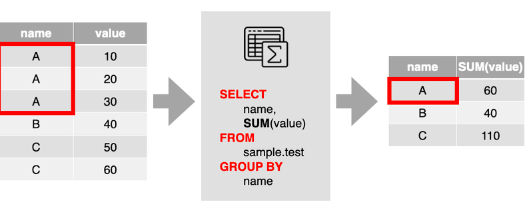
* 작성순서 : SELECT > FROM > WHERE > GROUP BY > ORDER BY > LIMIT
* GROUP BY는 집계함수와 함께 쓰인다.
* 특정 컬럼을 기준으로 그룹화할 수 있다.
* 건수, 합계 등의 집계적인 처리를 계산할 때 사용
* SELECT 절에 컬럼명, 집계함수가 같이 기술된 경우, 컬럼명은 GROUP BY에 기술되어야한다.
```sql
SELECT 컬럼1, SUM(컬럼)
FROM 테이블명
GROUP BY 컬럼1
```
* GROUP BY에 지정한 컬럼 이외의 컬럼은 집계함수를 사용하지 않은 채 SELECT 구문에 지정할 수 없다.
* 어떤 행을 출력해야하는지 알 수 없기 때문
* 결과값은 GROUP BY절에 기술된 컬럼 항목들의 행의 개수에 의해 결정된다.
* GROUP BY는 집계함수와 같이 쓰여야 그 힘을 발휘한다.
* 집계함수를 사용하지 않고도 사용할 수 있다.

In [10]:
# 평균 온도(temp)확인하기
mysql("""

SELECT AVG(temp) AS "평균온도"
FROM bike

""")

,평균온도
0,0.496987


In [11]:
# 계절과 온도의 RAW 데이터를 확인해보기
mysql("""

SELECT season, temp
FROM bike

""")

,season,temp
0,spring,0.24
1,spring,0.22
2,spring,0.22
3,spring,0.24
4,spring,0.24
...,...,...
17374,spring,0.26
17375,spring,0.26
17376,spring,0.26
17377,spring,0.26


In [12]:
# 계절별 평균 온도(temp)를 확인해보기, GROUP BY 뒤에는 컬럼명 뿐 아니라 숫자를 사용해도된다.
mysql("""

SELECT season AS "계절", AVG(temp) AS "평균온도"
FROM bike
GROUP BY season

""")

,계절,평균온도
0,fall,0.706410
1,spring,0.299147
2,summer,0.544663
3,winter,0.423138


In [13]:
# 시간대별 이용건수의 합계
mysql("""

SELECT hr AS "시간대", SUM(cnt) AS "이용건수합계" 
FROM bike
GROUP BY hr

""")

,시간대,이용건수합계
0,0,39130
1,1,24164
2,2,16352
3,3,8174
4,4,4428
5,5,14261
6,6,55132
7,7,154171
8,8,261001
9,9,159438


In [14]:
# 일자별과 날씨별 이용건수의 합계
#일자별 이용건수의 합계
mysql("""

SELECT dteday AS "이용 일자", SUM(cnt) AS "이용건수"
FROM bike
GROUP BY dteday


""")

,이용 일자,이용건수
0,2011-01-01,985
1,2011-01-02,801
2,2011-01-03,1349
3,2011-01-04,1562
4,2011-01-05,1600
...,...,...
726,2012-12-27,2114
727,2012-12-28,3095
728,2012-12-29,1341
729,2012-12-30,1796


In [15]:
# 날씨별 이용건수의 합계 
mysql("""

SELECT weathersit AS "날씨", SUM(cnt) AS "이용건수"
FROM bike
GROUP BY weathersit


""")

,날씨,이용건수
0,None,123
1,Clear,2338050
2,Cloudy,795952
3,LightRain,158331
4,Snow_Thunderstorm,223


# 그룹화한 데이터 조건주기(HAVING)
## HAVING

* 작성순서 : SELECT > FROM > WHERE > GROUP BY > HAVING > ORDER BY > LIMIT
* 집계함수를 사용하여 조건을 비교할 때 사용된다.
* 그룹의 결과를 제한하는 역할을 합니다.
* 그룹함수를 적용해서 나온 결과 중 원하는 조건에 부합하는 것만 필터링할 수 있다.
* 집계함수, 데이터 그룹핑을 통해 데이터를 특성별로 분류하거나 계산할 수 있다.

In [16]:
# 날씨별 이용건수의 합계 중 10만건 이상의 데이터만 확인
mysql("""

SELECT weathersit AS "날씨", SUM(cnt) AS "이용건수합계" 
FROM bike
GROUP BY 1
HAVING SUM(cnt) >= 100000

""")

,날씨,이용건수합계
0,Clear,2338050
1,Cloudy,795952
2,LightRain,158331


## WHERE와 HAVING의 차이

### WHERE
* 집계함수를 사용할 수 없습니다.
* 개별 행에 적용합니다.
* GROUP BY 전에 사용합니다.   
   
### HAVING
* 그룹에 적용합니다.
* GROUP BY 후에 사용합니다.

In [17]:
# WHERE와 HAVING의 차이를 아래의 두 가지 예시를 통해 알아봅시다.

# 온도가 0.3 이상인 계절과 온도 데이터를 필터링 해보기
mysql("""

SELECT season AS "계절", temp AS "온도"
FROM bike
WHERE temp >= 0.3

""")

,계절,온도
0,spring,0.32
1,spring,0.38
2,spring,0.36
3,spring,0.42
4,spring,0.46
...,...,...
14501,spring,0.30
14502,spring,0.30
14503,spring,0.30
14504,spring,0.30


In [18]:
# 계절별 평균 온도(temp)가 0.3 이상인 데이터를 필터링
mysql("""

SELECT season AS "계절", AVG(temp) AS "평균온도"
FROM bike
GROUP BY season
HAVING AVG(temp) >= 0.3

""")

,계절,평균온도
0,fall,0.706410
1,summer,0.544663
2,winter,0.423138
